In [90]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import LombScargle as ls
from photutils import aperture as ap
import scipy as sp
import glob
import datetime as dt # we run some things for a little while, it's nice to see how long

In [89]:
# first, import expected target locations from imdat
image_data = open('imdat3.2m0753', 'r')
line_list = []
for line in image_data:
    line_list.append(line.strip().split())
image_data.close()

In [3]:
stars_list = np.array(line_list[7:18], dtype=np.float64) # clip the imdat to just the stars we're interested in photometrically
# sdB is star number 5

# I would like to be able to use RA/DEC for per-image position correction, but unfortunately (like DS9), I cannot identify a supported mapping
# from image file to WCS in the header for our data images. The unit typing of each axis *seems* to imply that they are rectified and aligned with
# ra/dec, but I would really prefer to have any sort of standard CD matrix to justify that assumption, and I can accomplish what I need without it
# (I think), it's just more annoying.

In [4]:
# we're going to do dynamic fitting because I'm crazyyy
def SNR (image, x_pos, y_pos, r): # we need this for the scipy optimize call
    aper = ap.CircularAperture((x_pos, y_pos), r) # no dark current... odd. I won't give the signal or noise non-poisson error I suppose, this is all
    ann = ap.CircularAnnulus((x_pos, y_pos), 4/2.25*r, 6/2.25*r) # internal work anyways
    sum_ap = aper.do_photometry(image)[0]
    sky_err = ap.ApertureStats(image, ann).std*np.sqrt(aper.area) # among other things, I hadn't done a sky substraction, which was messing up my error. 
    # Ripped the previous calculations out and starting over again
    SNR = sum_ap/(np.sqrt(sum_ap) + sky_err) # agh!! forgot the *sqrt(area)! Now it gives values similar to what Dr. Green recommended

    # it's giving an SNR of 6000 for default values and scipy is refusing to optimize. This can't be an accurate error. Urg.
    # let's work through this. sky_err is the standard deviation of the sky background (the bulk of which has been subtracted off, not affecting its std)
    # times the sqrt size of the aperture. It is equivalent to the sky noise. However, there will also be poisson noise frrom the target, and we know for 
    # all counting noise that this is SUM sqrt(counts) -> err_ap. 
    # even if we count that, it's a bit of a struggle. Implementing a hard cap on target radius of 8 and leaving it alone.
    # need to check on this because it's bothering me. Taking poisson error as the sqrt of the total flux of the star but urghhh

    return SNR
    
# scipy needs a function to minimize, not maximize. Among other things, I want a separate function for it
def scipy_packer (params, image):
    x_pos, y_pos, r = params # r is the aperture radius in pixels
    SNR_val = SNR(image, x_pos, y_pos, r)
    return 1/SNR_val # should optimize fairly well

In [5]:
image = fits.open('reduced_images/2m0753.0197.fits')[0].data
x_pos, y_pos = stars_list[10,1:]
out = sp.optimize.minimize(scipy_packer, np.array([x_pos, y_pos, 5]), args=image, bounds=[(x_pos-5, x_pos+5),(y_pos-5, y_pos+5),(2, 8)])
print(out)

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.002375511328818969
        x: [ 9.034e+01  1.016e+03  5.186e+00]
      nit: 4
      jac: [ 7.971e-06  3.117e-06 -5.459e-06]
     nfev: 24
     njev: 6
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [6]:
1/out.fun

420.9619999990357

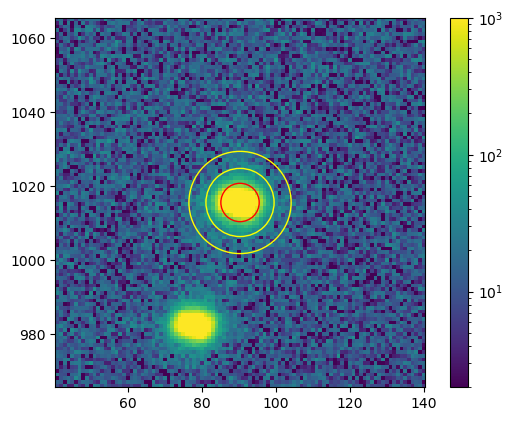

In [7]:
x_pos_opt, y_pos_opt, r_opt = out.x # it's incredible how quick these operations are. Just for me to remember if I ever get frustrated with them
opt_ap = ap.CircularAperture((x_pos_opt, y_pos_opt), r_opt)
opt_an = ap.CircularAnnulus((x_pos_opt, y_pos_opt), 4/2.25*r_opt, 6/2.25*r_opt)

plt.imshow(abs(image), norm='log', vmin=2, vmax=1000) # confirm that stars are being identified correctly - yes!
opt_ap.plot(color='red')
opt_an.plot(color='yellow')
plt.xlim(x_pos_opt-50, x_pos_opt+50)
plt.ylim(y_pos_opt-50, y_pos_opt+50)
plt.colorbar()

In [33]:
files_list = glob.glob('reduced_images/*.fits') # I hadn't initially checked, but yes this filelist should be sorted
files_list = np.sort(files_list)
HJD_arr, fluxes_arr = [], []
param_fits = [] # array to hold each of the parameterized fits of each image
j = 0 # just for some feedback about how fast it's going

for file in files_list:
    hdul = fits.open(file)
    image = hdul[0].data
    header = hdul[0].header # we can get some important info from this
    
    HJD = header['HJD'] # our time coordinate, some sort of super centered julian date
    HJD_arr.append(HJD)
    fluxes = [] # array to hold the fluxes of each star
    phot_params = []

    # we have a good guess for the position of each star over time in stars_list, but we would like to optimize for aperture and annulus SNR for each
    # star for each image. There's only 800 images, 11 stars, shouldn't be too bad
    # I happen to know that the typical displacement from aligned for each image was < 0.5 arcsec in either direction. At a pixel scale of 0.15 arcsec
    # /pix, a range of 10 pixels should be more than enough to optimize. We have from Dr. Green the recommendation of aperture radius 2.25xfwhm - .stats
    # file gives us fwhms, we could either read in that file or let the aperture radius vary from fwhm of 3 to 5 + flex room.
    # we have to stay under 18 px to avoid contamination from nearby neighbors, but that's easy. Again from Dr. Green, a decent sky region is 4xfwhm out 
    # to +2xfwhm (4x star aperture area. Technically sqrt(165)/2 - 4 but who's counting). I don't want to vary the sky annulus because I'm worried that 
    #dynamically modifying the error region will create perverse incentives. Also, I am just a *little* worried about processing time.
    # As Dr. Green mentions, we want to use one consistent radius for every star in the image.
    
    for i in range(np.shape(stars_list)[0]):
        x_pos, y_pos = stars_list[i,1], stars_list[i,2]
        guess = np.array([x_pos, y_pos, 5]) # assume FWHM ~ 4
        out = sp.optimize.minimize(scipy_packer, guess, args=image, bounds=[(x_pos-5, x_pos+5),(y_pos-5, y_pos+5),(2, 8)])
        phot_params.append(out.x) # it's incredible how quick these operations are. Just for me to remember if I ever get frustrated with them

    param_fits.append(phot_params) # so we can see what we converged to outside of the loop if we want
    r_opt = np.mean(np.array(phot_params), axis=0)[2] # the mean is a quick guess, I don't know if it's best... maybe max?
    if 6/2.25*r_opt > 18:
        print('possible overlap of star 11 in image', file)
    
    # to use one consistent aperture radius, we have to iterate through the list of stars twice, but that's okay
    for i in range(np.shape(stars_list)[0]):
        x_pos_opt, y_pos_opt = phot_params[i][0], phot_params[i][1] # we do NOT want to average the stellar positions, lol
        opt_ap = ap.CircularAperture((x_pos_opt, y_pos_opt), r_opt)
        opt_an = ap.CircularAnnulus((x_pos_opt, y_pos_opt), 4/2.25*r_opt, 6/2.25*r_opt)
        flux = opt_ap.do_photometry(image)[0]
        poisson_err = np.sqrt(flux) # is it appropriate to take the poisson error as the sqrt of the total flux? It is the total number of counts, and
        sky_err = ap.ApertureStats(image, opt_an).std*np.sqrt(opt_ap.area) # makes sense if you're adding in quadrature... hmm...
        tot_err = poisson_err + sky_err
        # both are of same order, poisson_err is dominant by ~3x

        fluxes.append([flux, tot_err])

    fluxes_arr.append(fluxes)
    
    if j%10 == 0:
        print(j)
        print(dt.datetime.now())
    j += 1
    
    hdul.close()

fluxes_arr = np.array(fluxes_arr)[:,:,:,0] # this array has the indexing format [image, star, flux/err]

0
2026-04-22 09:40:06.704130
10
2026-04-22 09:40:19.394163
20
2026-04-22 09:40:33.213308
30
2026-04-22 09:40:48.068214
40
2026-04-22 09:40:56.815580
50
2026-04-22 09:41:04.439483
60
2026-04-22 09:41:12.725176
70
2026-04-22 09:41:21.705061
80
2026-04-22 09:41:32.077388
90
2026-04-22 09:41:40.404255
100
2026-04-22 09:41:50.794557
110
2026-04-22 09:42:03.955183
120
2026-04-22 09:42:19.109505
130
2026-04-22 09:42:32.975238
140
2026-04-22 09:42:43.834779
150
2026-04-22 09:42:57.320820
160
2026-04-22 09:43:09.093826
170
2026-04-22 09:43:24.105407
180
2026-04-22 09:43:38.556494
190
2026-04-22 09:43:49.856358
200
2026-04-22 09:44:01.896775
210
2026-04-22 09:44:13.319318
220
2026-04-22 09:44:26.293687
230
2026-04-22 09:44:41.465518
240
2026-04-22 09:44:52.562133
250
2026-04-22 09:45:03.920114
260
2026-04-22 09:45:15.324676
270
2026-04-22 09:45:29.304357
280
2026-04-22 09:45:46.933734
290
2026-04-22 09:45:59.223719
300
2026-04-22 09:46:11.467903
310
2026-04-22 09:46:22.699058
320
2026-04-22 09:4

In [34]:
# should probably do out with pandas, but save the numpy arrays just to be sure
np.save('fluxes_1.2', fluxes_arr)
np.save('HJD_1.2', HJD_arr)

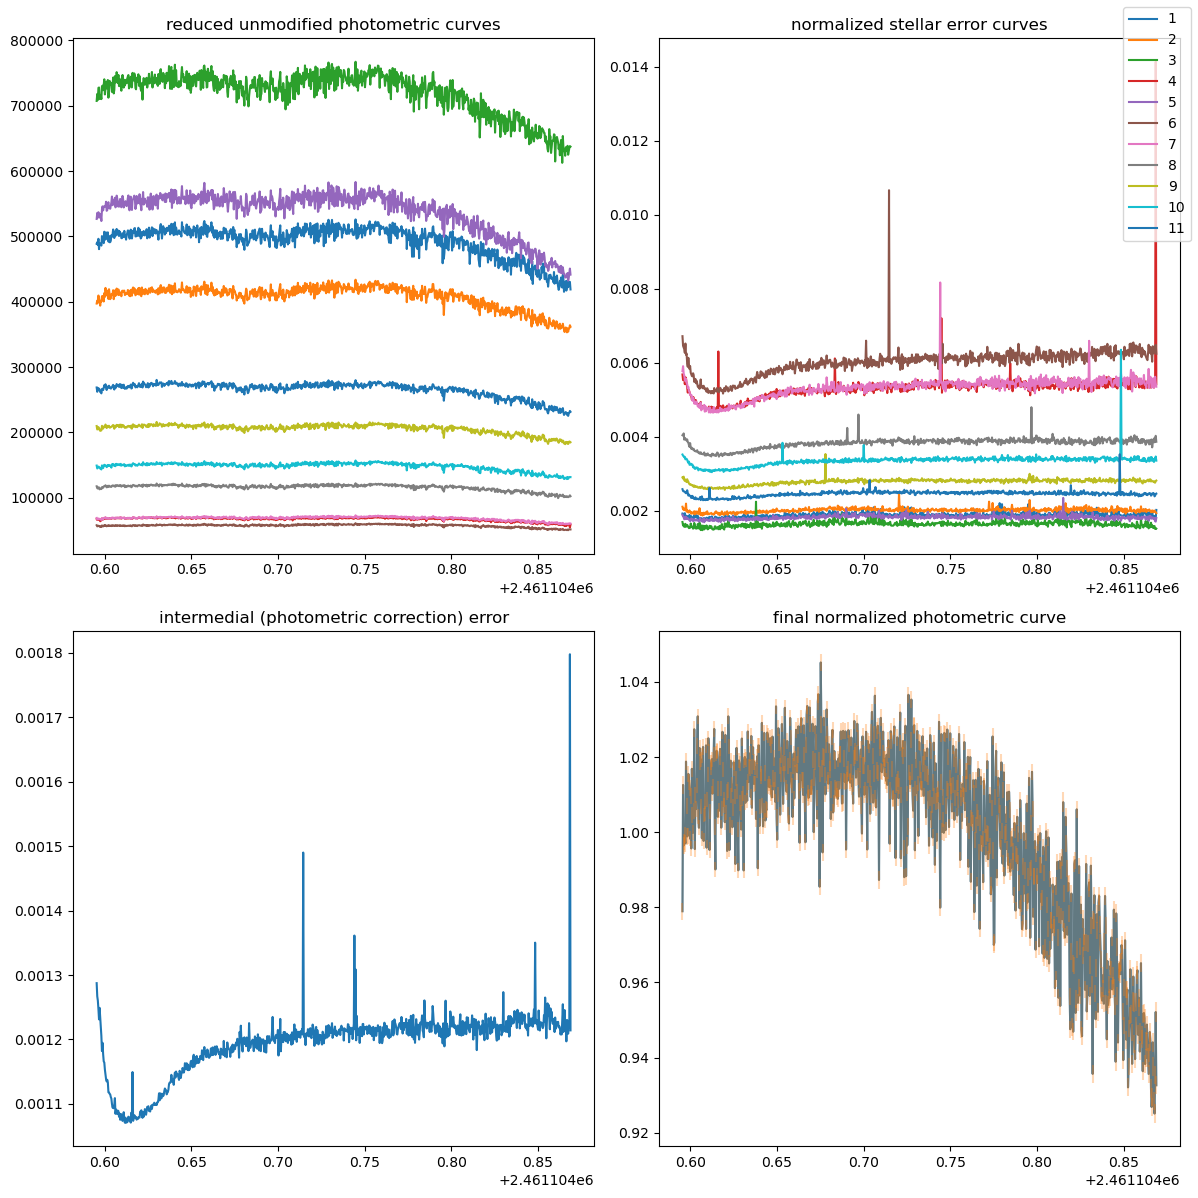

<Figure size 640x480 with 0 Axes>

In [37]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax[0,0].plot(HJD_arr, fluxes_arr[:,:,0], label=['1','2','3','4','5','6','7','8','9','10','11'])
ax[0,0].set_title('reduced unmodified photometric curves')
fig.legend()

# relative photometry and error processing:
stellar_means = np.mean(fluxes_arr[:,:,0], axis=0) # normalize each star relative to itself first. Scale both magnitude and errorbars by the same amount
norm_stars = fluxes_arr/np.transpose([stellar_means,stellar_means]) # kind of janky because numpy cannot read my mind
target_star = norm_stars[:,4,:] # fluxes and photometric error of target star
other_stars = np.concatenate([norm_stars[:,:4,:], norm_stars[:,5:,:]], axis=1)
phot_corr = np.mean(other_stars[:,:,0], axis=1) # the photometric correction factor = mean measured brightness of all calibration stars in that image
ax[0,1].plot(HJD_arr, norm_stars[:,:,1])
ax[0,1].set_title('normalized stellar error curves')

# the error in the photometric correction factor is the propagated error from each data point, which is the sum in quadrature over the constant factor N 
# as per traditional Taylor error propagation. We do *not* need the standard error of the estimator sigma/sqrt(N) - technically, the mean isn't even the
# ideal estimator for data points with known distributions, but suffice it to say we can be content with just the propagated error.
plt.figure()
#phot_sig = np.std(other_stars[:,:,0], axis=1)/np.sqrt(np.shape(other_stars)[1]) 
err_phot = np.sqrt(np.sum(other_stars[:,:,1]**2, axis=1))/np.shape(other_stars)[1]
#ax[1,0].plot(HJD_arr, err_prop)
ax[1,0].plot(HJD_arr, err_phot)
ax[1,0].set_title('intermedial (photometric correction) error')

# now, the final quantity is our star over the mean of every other star:
corr_target = target_star[:,0]/phot_corr
# the corresponding error, according to error prop, is y = u/v -> sy^2 = (su/v0)^2 + (-u0*sv/v0^2)^2 = ((su)^2 + (u0*sv/v0)^2)/v0^2
tot_err = np.sqrt((target_star[:,1])**2 + (target_star[:,0]*err_phot/phot_corr)**2)/phot_corr

ax[1,1].plot(HJD_arr, corr_target)
ax[1,1].errorbar(HJD_arr, corr_target, tot_err, alpha=0.3)
#ax[1,1].set_xlim(0.65+2461104,0.75+2461104)
ax[1,1].set_title('final normalized photometric curve')

fig
fig.tight_layout()

In [91]:
# read in FWHMs from 2m0753.stats for comparison
fwhm_file = open('2m0753.stats', 'r')
fwhms = []
i = 0
for line in fwhm_file:
    if i >= 6:
        fwhms.append(float(line.strip().split('       ')[-1]))
    i += 1
fwhm_file.close()

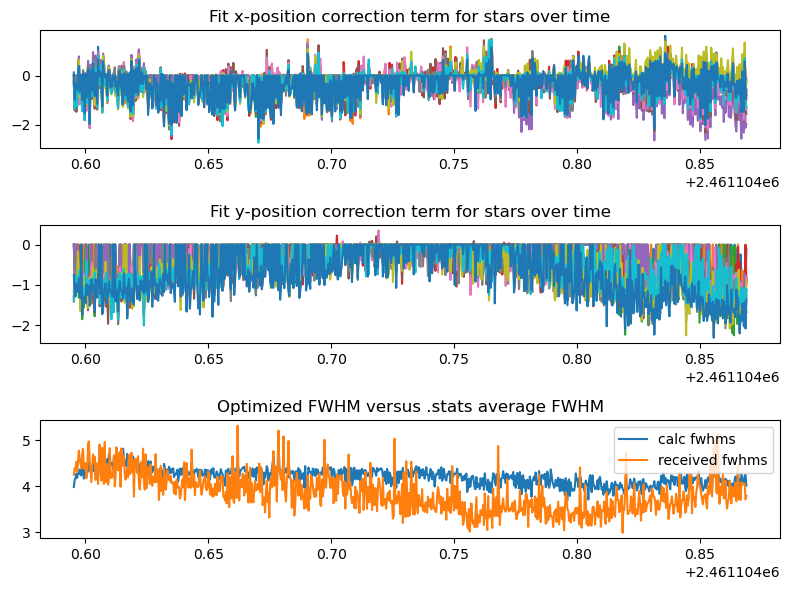

In [92]:
# plots of the aperture and annulus parameters relative to the given values
param_array = np.array(param_fits)

fig2, ax2 = plt.subplots(3, figsize=(8,6))

ax2[0].plot(HJD_arr, param_array[:,:,0] - stars_list[:,1])
ax2[0].set_title('Fit x-position correction term for stars over time')
ax2[1].plot(HJD_arr, param_array[:,:,1] - stars_list[:,2])
ax2[1].set_title('Fit y-position correction term for stars over time')
ax2[2].plot(HJD_arr, (2/2.25)*np.mean(param_array, axis=1)[:,2], label='calc fwhms')
ax2[2].plot(HJD_arr, fwhms, label='received fwhms')
ax2[2].set_title('Optimized FWHM versus .stats average FWHM')
ax2[2].legend()
fig2.tight_layout()

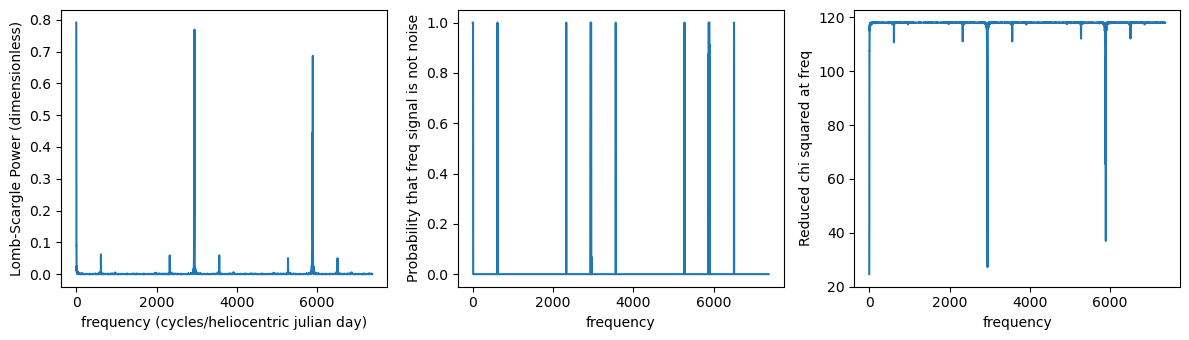

In [117]:
# frequency analysis
periodogram = ls(HJD_arr, corr_target, tot_err)
freq, power = periodogram.autopower()

freq_junk, power_extra = ls(HJD_arr, corr_target, tot_err, normalization='psd').autopower()
prob_noise_given_data = periodogram.false_alarm_probability(power)
chi_sq = 2*power_extra*(1-power)/power

fig3, ax3 = plt.subplots(1, 3, figsize=(12,3.5))
ax3[0].plot(freq, power)
ax3[0].set_ylabel('Lomb-Scargle Power (dimensionless)')
ax3[0].set_xlabel('frequency (cycles/heliocentric julian day)')

ax3[1].plot(freq, 1-prob_noise_given_data)
ax3[1].set_ylabel('Probability that freq signal is not noise')
ax3[1].set_xlabel('frequency')

ax3[2].plot(freq, chi_sq/(len(HJD_arr)-3)) # there are three model parameters
ax3[2].set_ylabel('Reduced chi squared at freq')
ax3[2].set_xlabel('frequency')

fig3.tight_layout()
# need to compute units

# proper nyquist factor for LS is as follows: suppose there is some factor p, such that every ti = t0 + n*p for some integer n. The nyquist frequency
# is 1/2p. More likely, however, frequency limit is determined by the time-width of the integration, which was 18 seconds. This means we cannot see
# anything under 1/36 Hz, which is 2400 cycles per day.
# generally the fit for each frequency model chi_sq = chi_sq_ref*(1 - Power)
# unfortunately, I cannot get a method to obtain the reference chi_sq, but I can recompute it through nonsense:
# chi_sq_ref = chi_sq * (P_model + 1)
# => chi_sq = chi_sq * (P_model + 1) * (1 - Power) seriously?? AGHH
# chi_sq_ref = 2*P_psd + chi_sq
# => chi_sq = 2*P_psd*(1-Power)/Power okay finally

# from https://docs.astropy.org/en/stable/timeseries/lombscargle.html#lomb-scargle-normalization, 
# https://iopscience.iop.org/article/10.3847/1538-4365/aab766